In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

In [3]:
# 1. 데이터 로드
url = "https://raw.githubusercontent.com/kzming2007/UR3_Cobot_ML/refs/heads/main/dataset/ur3_cobotops.csv"
df = pd.read_csv(url)

## Regression To Classification, Logistic Regression

### Cell 1: 라이브러리 및 데이터 로드

In [4]:
# 2. 결측치 없는 클린 데이터 분리
df_clean = df.dropna().copy()

# 3. 파생 변수 생성 (정지 상태 판단)
speed_cols = ['Speed_J0', 'Speed_J1', 'Speed_J2', 'Speed_J3', 'Speed_J4', 'Speed_J5']
df_clean['is_stationary'] = (df_clean[speed_cols].abs().sum(axis=1) < 0.05).astype(int)

# 4. 입력 피처(X) 설정
input_cols = [
    'Current_J0', 'Current_J1', 'Current_J2', 'Current_J3', 'Current_J4', 'Current_J5',
    'Speed_J0', 'Speed_J1', 'Speed_J2', 'Speed_J3', 'Speed_J4', 'Speed_J5',
    'is_stationary'
]
X = df_clean[input_cols]

print(f"데이터 크기: {df_clean.shape}")
print(f"피처 개수: {len(input_cols)}개")

데이터 크기: (7355, 25)
피처 개수: 13개


### Cell 2: 타겟 변수 라벨링

In [5]:
# 연속형 Tool_current 값을 3개의 물리적 상태 범주로 변환하는 함수
def categorize_current(val):
    if val < 0.12:
        return 0  # 대기 상태 (Standby)
    elif val < 0.35:
        return 1  # 전이 상태 (Transition)
    else:
        return 2  # 파지 상태 (Gripping)
    #else:
        return 1  # 파지 상태 (Gripping)


# 새로운 범주형 타겟(y) 생성
y = df_clean['Tool_current'].apply(categorize_current)

print("분류된 타겟(y)의 클래스별 데이터 개수:")
print(y.value_counts().sort_index())

분류된 타겟(y)의 클래스별 데이터 개수:
Tool_current
0    6337
1     756
2     262
Name: count, dtype: int64


### Cell 3: 데이터 분할 및 스케일링

In [6]:
# 1. Train / Test Split (클래스 비율을 유지하기 위해 stratify=y 적용)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 2. 데이터 스케일링 (로지스틱 회귀는 변수 스케일에 민감함)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"학습 데이터 크기: {X_train_scaled.shape}")
print(f"테스트 데이터 크기: {X_test_scaled.shape}")

학습 데이터 크기: (5884, 13)
테스트 데이터 크기: (1471, 13)


### Cell 4: Logistic Regression 학습 및 하이퍼파라미터 튜닝

In [7]:
# 1. Stratified K-Fold 설정 (클래스 비율 유지)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 2. 로지스틱 회귀 기본 모델 생성 (데이터 불균형 해결을 위해 class_weight='balanced' 필수)
log_reg = LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000)

# 3. 튜닝할 파라미터 그리드 (규제 강도 C와 페널티 종류 설정)
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],           # 규제 강도 (작을수록 규제가 강함)
    'penalty': ['l1', 'l2'],                # L1(Lasso 성격), L2(Ridge 성격) 규제
    'solver': ['saga']                      #L1/L2 모두 지원하는 최적화 알고리즘
}

# 4. GridSearchCV 실행 (데이터 불균형을 고려해 scoring을 'f1_macro'로 설정)
print("--- Logistic Regression 하이퍼파라미터 탐색 및 5-Fold 교차 검증 진행 중 ---")
grid_search_lr = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid,
    cv=skf,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

grid_search_lr.fit(X_train_scaled, y_train)

# 5. 최적 파라미터 및 결과 확인
print("\n[GridSearchCV 결과]")
print("[최적의 하이퍼파라미터 설정]")
for param, value in grid_search_lr.best_params_.items():
    print(f"  • {param}: {value}")
print("")
print(f"최고 교차 검증 F1-Macro 점수: {grid_search_lr.best_score_:.4f}")

--- Logistic Regression 하이퍼파라미터 탐색 및 5-Fold 교차 검증 진행 중 ---
Fitting 5 folds for each of 10 candidates, totalling 50 fits

[GridSearchCV 결과]
[최적의 하이퍼파라미터 설정]
  • C: 1
  • penalty: l2
  • solver: saga

최고 교차 검증 F1-Macro 점수: 0.4887


### Cell 5: 상위 10개 모델 비교 데이터프레임 & 최종 평가

In [8]:
# 1. GridSearchCV 결과에서 상위 10개 모델 추출
cv_results_df = pd.DataFrame(grid_search_lr.cv_results_)
top_models = cv_results_df.sort_values('rank_test_score').head(10)

# 비교 결과를 담을 리스트
comparison_data = []

print("--- [모델 비교] 상위 10개 Logistic Regression 성능 종합 ---")

# 2. 상위 모델들을 하나씩 돌려가며 Train/Test 평가 진행
for index, row in top_models.iterrows():
    params = row['params']
    rank = int(row['rank_test_score'])
    cv_f1 = row['mean_test_score']

    # 해당 파라미터로 모델 재학습
    model = LogisticRegression(**params, random_state=42, class_weight='balanced', max_iter=1000)
    model.fit(X_train_scaled, y_train)

    # 예측
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)

    # 평가지표 계산 (분류에서는 R2 대신 F1-Macro와 Accuracy 사용)
    train_f1 = f1_score(y_train, y_train_pred, average='macro')
    test_f1 = f1_score(y_test, y_test_pred, average='macro')
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    # 파라미터 설정을 간소화된 문자열로 변환 (예: C=10, P=l2, S=liblinear)
    c_val = params.get('C', '-')
    pen_val = params.get('penalty', '-')
    sol_val = params.get('solver', '-')
    param_short = f"C={c_val}, P={pen_val}, S={sol_val}"

    # 결과 저장 (과적합 정도를 보기 위해 Train F1 - Test F1 Gap 추가)
    comparison_data.append({
        '순위': rank,
        'CV F1': round(cv_f1, 4),
        'Train F1': round(train_f1, 4),
        'Test F1': round(test_f1, 4),
        '과적합 Gap': round(train_f1 - test_f1, 4),
        'Train Acc': round(train_acc, 6),
        'Test Acc': round(test_acc, 6),
        '파라미터 설정': param_short
    })

# 3. 비교 결과를 데이터프레임으로 출력 (Jupyter에서 표 형태로 예쁘게 출력됨)
comparison_df = pd.DataFrame(comparison_data)
display(comparison_df)

--- [모델 비교] 상위 10개 Logistic Regression 성능 종합 ---


,순위,CV F1,Train F1,Test F1,과적합 Gap,Train Acc,Test Acc,파라미터 설정
0,1,0.4887,0.4830,0.4567,0.0263,0.657206,0.662135,"C=1, P=l2, S=saga"
1,2,0.4876,0.4869,0.4599,0.0270,0.660095,0.665534,"C=10, P=l2, S=saga"
2,3,0.4871,0.4879,0.4592,0.0287,0.661455,0.665534,"C=100, P=l1, S=saga"
3,4,0.4870,0.4874,0.4589,0.0285,0.660775,0.664854,"C=10, P=l1, S=saga"
4,5,0.4867,0.4879,0.4593,0.0286,0.661455,0.665534,"C=100, P=l2, S=saga"
5,6,0.4857,0.4862,0.4594,0.0268,0.659925,0.664174,"C=1, P=l1, S=saga"
6,7,0.4774,0.4798,0.4555,0.0242,0.649388,0.655337,"C=0.1, P=l2, S=saga"
7,8,0.4731,0.4751,0.4541,0.0210,0.642930,0.647179,"C=0.1, P=l1, S=saga"
8,9,0.4587,0.4631,0.4420,0.0211,0.609619,0.616587,"C=0.01, P=l2, S=saga"
9,10,0.4447,0.4504,0.4406,0.0098,0.564072,0.585996,"C=0.01, P=l1, S=saga"


### Cell 6: 특정 순위 모델 최종 평가지표 상세 분석

In [9]:
print("\n" + "="*50)
target_rank = 2  # 분석하고 싶은 순위를 여기에 입력하세요 (예: 1, 2, 3...)
print(f"--- [상세 분석] {target_rank}위 모델 최종 평가지표 ---")
print("="*50)

# 1. Cell 5-2에서 생성된 top_models에서 원하는 순위의 파라미터 추출
# 중복 순위가 있을 수 있으므로 첫 번째(.iloc[0]) 모델을 가져옵니다.
selected_row = top_models[top_models['rank_test_score'] == target_rank].iloc[0]
selected_params = selected_row['params']

print(f"\n[선택된 {target_rank}위 모델의 하이퍼파라미터]")
for param, value in selected_params.items():
    print(f"  • {param}: {value}")

# 2. 추출한 파라미터로 모델 재학습
selected_lr = LogisticRegression(**selected_params, random_state=42, class_weight='balanced', max_iter=1000)
selected_lr.fit(X_train_scaled, y_train)

# 3. 예측 수행
y_train_pred_selected = selected_lr.predict(X_train_scaled)
y_test_pred_selected = selected_lr.predict(X_test_scaled)

# 4. 평가지표 출력 함수
def print_metrics(y_true, y_pred, dataset_name):
    acc = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average='macro')

    print(f"\n[{dataset_name} 데이터 평가]")
    print(f"Accuracy (정확도) : {acc:.4f}")
    print(f"F1-Macro Score    : {f1_macro:.6f}")

    print(f"\n[{dataset_name} 상세 분류 리포트]")
    print(classification_report(y_true, y_pred, target_names=['0 (Standby)', '1 (Transition)', '2 (Gripping)']))

# 5. Train / Test 결과 출력
print_metrics(y_train, y_train_pred_selected, "Train")
print_metrics(y_test, y_test_pred_selected, "Test")

# Cell 7에서 선택된 모델의 오차 행렬(Confusion Matrix)이 그려지도록 변수 연결
y_test_pred = y_test_pred_selected


--- [상세 분석] 2위 모델 최종 평가지표 ---

[선택된 2위 모델의 하이퍼파라미터]
  • C: 10
  • penalty: l2
  • solver: saga

[Train 데이터 평가]
Accuracy (정확도) : 0.6601
F1-Macro Score    : 0.486929

[Train 상세 분류 리포트]
                precision    recall  f1-score   support

   0 (Standby)       0.97      0.65      0.78      5070
1 (Transition)       0.24      0.77      0.37       605
  2 (Gripping)       0.22      0.57      0.31       209

      accuracy                           0.66      5884
     macro avg       0.48      0.66      0.49      5884
  weighted avg       0.87      0.66      0.72      5884


[Test 데이터 평가]
Accuracy (정확도) : 0.6655
F1-Macro Score    : 0.459895

[Test 상세 분류 리포트]
                precision    recall  f1-score   support

   0 (Standby)       0.97      0.66      0.79      1267
1 (Transition)       0.26      0.80      0.39       151
  2 (Gripping)       0.14      0.36      0.20        53

      accuracy                           0.67      1471
     macro avg       0.46      0.61      0.46      14

### Cell 7: 오차 행렬(Confusion Matrix) 시각화

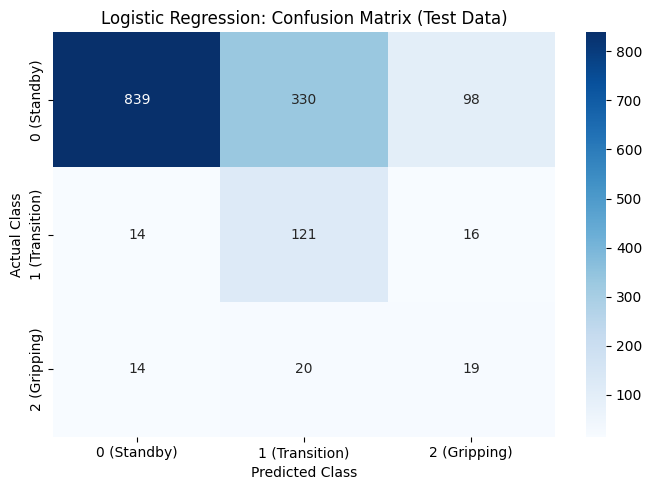

In [10]:
# 분류 모델의 예측 결과를 눈으로 확인하기 위한 오차 행렬 시각화
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['0 (Standby)', '1 (Transition)', '2 (Gripping)'],
            yticklabels=['0 (Standby)', '1 (Transition)', '2 (Gripping)'])

plt.title('Logistic Regression: Confusion Matrix (Test Data)')
plt.ylabel('Actual Class')
plt.xlabel('Predicted Class')
plt.tight_layout()
plt.show()

###Cell 8: SMOTE 적용


In [11]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)
from collections import Counter

print(Counter(y_train))
print(Counter(y_train_smote))

Counter({0: 5070, 1: 605, 2: 209})
Counter({0: 5070, 2: 5070, 1: 5070})


###Cell 9: SMOTE 적용 후 모델 학습

In [12]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression

# 1. Stratified K-Fold 설정
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# 2. 로지스틱 회귀 모델
log_reg = LogisticRegression(
    random_state=42,
    max_iter=1000
)

# 3. 파라미터 그리드
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['saga']
}

# 4. GridSearchCV
grid_search_lr = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid,
    cv=skf,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

# 이미 SMOTE 적용된 데이터 사용
grid_search_lr.fit(X_train_smote, y_train_smote)

# 결과 출력
print("\n[최적의 하이퍼파라미터]")
print(grid_search_lr.best_params_)
print(f"최고 CV F1-Macro: {grid_search_lr.best_score_:.4f}")

Fitting 5 folds for each of 10 candidates, totalling 50 fits

[최적의 하이퍼파라미터]
{'C': 100, 'penalty': 'l1', 'solver': 'saga'}
최고 CV F1-Macro: 0.6834


###Cell 10: SMOTE 적용 후 상위 10개 모델 비교

In [13]:
# 1. GridSearchCV 결과에서 상위 10개 모델 추출
cv_results_df = pd.DataFrame(grid_search_lr.cv_results_)
top_models = cv_results_df.sort_values('rank_test_score').head(10)

# 비교 결과를 담을 리스트
comparison_data = []

print("--- [모델 비교] 상위 10개 Logistic Regression 성능 종합 ---")

# 2. 상위 모델들을 하나씩 돌려가며 Train/Test 평가 진행
for index, row in top_models.iterrows():
    params = row['params']
    rank = int(row['rank_test_score'])
    cv_f1 = row['mean_test_score']

    # 해당 파라미터로 모델 재학습
    model = LogisticRegression(**params, random_state=42, max_iter=1000)
    model.fit(X_train_smote, y_train_smote)

    # 예측
    y_train_pred = model.predict(X_train_smote)
    y_test_pred = model.predict(X_test_scaled)

    # 평가지표 계산 (분류에서는 R2 대신 F1-Macro와 Accuracy 사용)
    train_f1 = f1_score(y_train_smote, y_train_pred, average='macro')
    test_f1 = f1_score(y_test, y_test_pred, average='macro')
    train_acc = accuracy_score(y_train_smote, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    # 파라미터 설정을 간소화된 문자열로 변환 (예: C=10, P=l2, S=liblinear)
    c_val = params.get('C', '-')
    pen_val = params.get('penalty', '-')
    sol_val = params.get('solver', '-')
    param_short = f"C={c_val}, P={pen_val}, S={sol_val}"

    # 결과 저장 (과적합 정도를 보기 위해 Train F1 - Test F1 Gap 추가)
    comparison_data.append({
        '순위': rank,
        'CV F1': round(cv_f1, 4),
        'Train F1': round(train_f1, 4),
        'Test F1': round(test_f1, 4),
        '과적합 Gap': round(train_f1 - test_f1, 4),
        'Train Acc': round(train_acc, 6),
        'Test Acc': round(test_acc, 6),
        '파라미터 설정': param_short
    })

# 3. 비교 결과를 데이터프레임으로 출력 (Jupyter에서 표 형태로 예쁘게 출력됨)
comparison_df = pd.DataFrame(comparison_data)
display(comparison_df)

--- [모델 비교] 상위 10개 Logistic Regression 성능 종합 ---


,순위,CV F1,Train F1,Test F1,과적합 Gap,Train Acc,Test Acc,파라미터 설정
0,1,0.6834,0.6847,0.4703,0.2145,0.685667,0.685248,"C=100, P=l1, S=saga"
1,2,0.6833,0.6845,0.4703,0.2142,0.685404,0.685248,"C=100, P=l2, S=saga"
2,3,0.6831,0.6845,0.4703,0.2143,0.685470,0.685248,"C=10, P=l1, S=saga"
3,4,0.6825,0.6833,0.4681,0.2152,0.684287,0.681849,"C=10, P=l2, S=saga"
4,5,0.6820,0.6826,0.4681,0.2145,0.683563,0.681849,"C=1, P=l1, S=saga"
5,6,0.6769,0.6786,0.4601,0.2185,0.679619,0.675731,"C=1, P=l2, S=saga"
6,7,0.6686,0.6732,0.4613,0.2119,0.674096,0.673691,"C=0.1, P=l1, S=saga"
7,8,0.6654,0.6676,0.4610,0.2065,0.669165,0.674371,"C=0.1, P=l2, S=saga"
8,9,0.6515,0.6533,0.4509,0.2024,0.655687,0.651258,"C=0.01, P=l2, S=saga"
9,10,0.6504,0.6515,0.4500,0.2015,0.653452,0.636302,"C=0.01, P=l1, S=saga"


### Cell 11: 특정 순위 모델 최종 평가지표 상세 분석

In [14]:
print("\n" + "="*50)
target_rank = 2  # 분석하고 싶은 순위를 여기에 입력하세요 (예: 1, 2, 3...)
print(f"--- [상세 분석] {target_rank}위 모델 최종 평가지표 ---")
print("="*50)

# 1. Cell 5-2에서 생성된 top_models에서 원하는 순위의 파라미터 추출
# 중복 순위가 있을 수 있으므로 첫 번째(.iloc[0]) 모델을 가져옵니다.
selected_row = top_models[top_models['rank_test_score'] == target_rank].iloc[0]
selected_params = selected_row['params']

print(f"\n[선택된 {target_rank}위 모델의 하이퍼파라미터]")
for param, value in selected_params.items():
    print(f"  • {param}: {value}")

# 2. 추출한 파라미터로 모델 재학습
selected_lr = LogisticRegression(**selected_params, random_state=42, max_iter=1000)
selected_lr.fit(X_train_smote, y_train_smote)

# 3. 예측 수행
y_train_pred_selected = selected_lr.predict(X_train_smote)
y_test_pred_selected = selected_lr.predict(X_test_scaled)

# 4. 평가지표 출력 함수
def print_metrics(y_true, y_pred, dataset_name):
    acc = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average='macro')

    print(f"\n[{dataset_name} 데이터 평가]")
    print(f"Accuracy (정확도) : {acc:.4f}")
    print(f"F1-Macro Score    : {f1_macro:.6f}")

    print(f"\n[{dataset_name} 상세 분류 리포트]")
    print(classification_report(y_true, y_pred, target_names=['0 (Standby)', '1 (Transition)', '2 (Gripping)']))

# 5. Train / Test 결과 출력
print_metrics(y_train_smote, y_train_pred_selected, "Train")
print_metrics(y_test, y_test_pred_selected, "Test")

# Cell 7에서 선택된 모델의 오차 행렬(Confusion Matrix)이 그려지도록 변수 연결
y_test_pred = y_test_pred_selected


--- [상세 분석] 2위 모델 최종 평가지표 ---

[선택된 2위 모델의 하이퍼파라미터]
  • C: 100
  • penalty: l2
  • solver: saga

[Train 데이터 평가]
Accuracy (정확도) : 0.6854
F1-Macro Score    : 0.684463

[Train 상세 분류 리포트]
                precision    recall  f1-score   support

   0 (Standby)       0.70      0.68      0.69      5070
1 (Transition)       0.62      0.78      0.69      5070
  2 (Gripping)       0.76      0.60      0.67      5070

      accuracy                           0.69     15210
     macro avg       0.70      0.69      0.68     15210
  weighted avg       0.70      0.69      0.68     15210


[Test 데이터 평가]
Accuracy (정확도) : 0.6852
F1-Macro Score    : 0.470266

[Test 상세 분류 리포트]
                precision    recall  f1-score   support

   0 (Standby)       0.97      0.69      0.80      1267
1 (Transition)       0.27      0.77      0.41       151
  2 (Gripping)       0.14      0.38      0.20        53

      accuracy                           0.69      1471
     macro avg       0.46      0.61      0.47      1

###Confusion Matrix 시각화

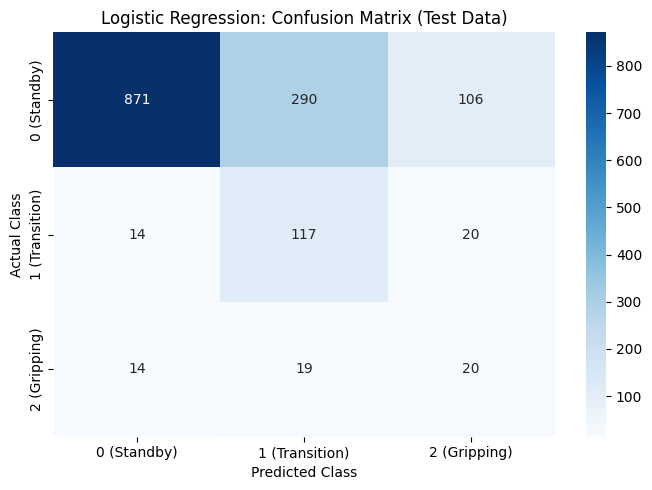

In [15]:
# 분류 모델의 예측 결과를 눈으로 확인하기 위한 오차 행렬 시각화
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['0 (Standby)', '1 (Transition)', '2 (Gripping)'],
            yticklabels=['0 (Standby)', '1 (Transition)', '2 (Gripping)'])

plt.title('Logistic Regression: Confusion Matrix (Test Data)')
plt.ylabel('Actual Class')
plt.xlabel('Predicted Class')
plt.tight_layout()
plt.show()

In [16]:
from collections import Counter

print(Counter(y_train))
print(Counter(y_train_smote))
print(classification_report(y_test, y_test_pred))

Counter({0: 5070, 1: 605, 2: 209})
Counter({0: 5070, 2: 5070, 1: 5070})
              precision    recall  f1-score   support

           0       0.97      0.69      0.80      1267
           1       0.27      0.77      0.41       151
           2       0.14      0.38      0.20        53

    accuracy                           0.69      1471
   macro avg       0.46      0.61      0.47      1471
weighted avg       0.87      0.69      0.74      1471



#Random Forest

###SMOTE 적용 X. 원본 데이터로 Random Forest 진행

In [23]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV

# Stratified K-Fold
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Random Forest
rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

# 파라미터 그리드
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# GridSearchCV
grid_search_rf_original = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_rf,
    cv=skf,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

# ★ 원본 데이터 사용
grid_search_rf_original.fit(
    X_train_scaled,
    y_train
)

print("\n[최적의 하이퍼파라미터]")
print(grid_search_rf_original.best_params_)

print(f"\n최고 CV F1-Macro: {grid_search_rf_original.best_score_:.4f}")

Fitting 5 folds for each of 16 candidates, totalling 80 fits

[최적의 하이퍼파라미터]
{'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

최고 CV F1-Macro: 0.8275


###테스트 성능 확인

In [24]:
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score, f1_score

best_rf_original = grid_search_rf_original.best_estimator_

y_test_pred_rf_original = best_rf_original.predict(
    X_test_scaled
)

print("Accuracy:",
      accuracy_score(y_test, y_test_pred_rf_original))

print("Macro F1:",
      f1_score(
          y_test,
          y_test_pred_rf_original,
          average='macro'
      ))

print("\nClassification Report")

print(
    classification_report(
        y_test,
        y_test_pred_rf_original,
        target_names=[
            '0 (Standby)',
            '1 (Transition)',
            '2 (Gripping)'
        ]
    )
)

Accuracy: 0.9456152277362339
Macro F1: 0.7881563811790026

Classification Report
                precision    recall  f1-score   support

   0 (Standby)       0.96      0.99      0.97      1267
1 (Transition)       0.85      0.78      0.81       151
  2 (Gripping)       0.80      0.45      0.58        53

      accuracy                           0.95      1471
     macro avg       0.87      0.74      0.79      1471
  weighted avg       0.94      0.95      0.94      1471



###Feature 중요도 분석 및 시각화

In [25]:
import pandas as pd

# 중요도 추출
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_rf_original.feature_importances_
})

# 중요도 순으로 정렬
importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

print("--- Feature Importance 순위 ---")
display(importance_df)

--- Feature Importance 순위 ---


,Feature,Importance
5,Current_J5,0.118525
3,Current_J3,0.108128
2,Current_J2,0.101922
1,Current_J1,0.096541
11,Speed_J5,0.095138
6,Speed_J0,0.078961
0,Current_J0,0.078354
4,Current_J4,0.076689
9,Speed_J3,0.065008
12,is_stationary,0.048814


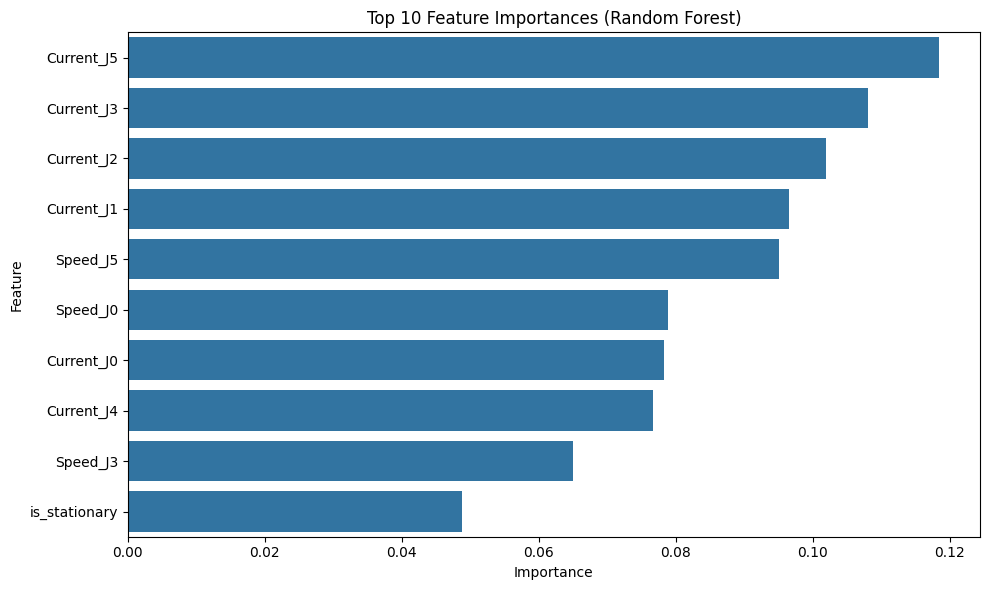

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

top10 = importance_df.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top10,
    x='Importance',
    y='Feature'
)

plt.title('Top 10 Feature Importances (Random Forest)')
plt.xlabel('Importance')
plt.ylabel('Feature')

plt.tight_layout()
plt.show()

###Random Forest + SMOTE(Pipeline) + GridSearchCV

In [28]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import GridSearchCV

# 1. Stratified K-Fold
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# 2. Pipeline 구성
pipeline_rf = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('rf', RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ))
])

# 3. 파라미터 그리드
param_grid_rf = {
    'rf__n_estimators': [100, 200],
    'rf__max_depth': [10, 20],
    'rf__min_samples_split': [2, 5],
    'rf__min_samples_leaf': [1, 2]
}

# 4. GridSearchCV
grid_search_rf_pipeline = GridSearchCV(
    estimator=pipeline_rf,
    param_grid=param_grid_rf,
    cv=skf,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

# 5. 학습
grid_search_rf_pipeline.fit(
    X_train_scaled,
    y_train
)

print("\n[최적의 하이퍼파라미터]")
print(grid_search_rf_pipeline.best_params_)

print(
    f"\n최고 CV F1-Macro: "
    f"{grid_search_rf_pipeline.best_score_:.4f}"
)

Fitting 5 folds for each of 16 candidates, totalling 80 fits

[최적의 하이퍼파라미터]
{'rf__max_depth': 20, 'rf__min_samples_leaf': 1, 'rf__min_samples_split': 5, 'rf__n_estimators': 200}

최고 CV F1-Macro: 0.8497


###테스트 성능 평가

In [29]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report

best_rf_pipeline = grid_search_rf_pipeline.best_estimator_

y_test_pred_pipeline = best_rf_pipeline.predict(
    X_test_scaled
)

print(
    "Accuracy:",
    accuracy_score(y_test, y_test_pred_pipeline)
)

print(
    "Macro F1:",
    f1_score(
        y_test,
        y_test_pred_pipeline,
        average='macro'
    )
)

print(
    classification_report(
        y_test,
        y_test_pred_pipeline,
        target_names=[
            '0 (Standby)',
            '1 (Transition)',
            '2 (Gripping)'
        ]
    )
)

Accuracy: 0.9449354180829368
Macro F1: 0.7932683420380635
                precision    recall  f1-score   support

   0 (Standby)       0.98      0.97      0.98      1267
1 (Transition)       0.80      0.87      0.84       151
  2 (Gripping)       0.53      0.60      0.57        53

      accuracy                           0.94      1471
     macro avg       0.77      0.82      0.79      1471
  weighted avg       0.95      0.94      0.95      1471



###Confusion Matrix

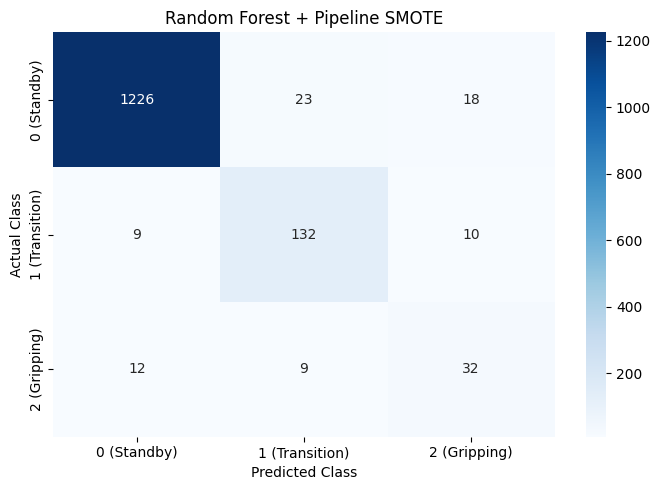

In [30]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_test_pred_pipeline
)

plt.figure(figsize=(7,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=[
        '0 (Standby)',
        '1 (Transition)',
        '2 (Gripping)'
    ],
    yticklabels=[
        '0 (Standby)',
        '1 (Transition)',
        '2 (Gripping)'
    ]
)

plt.title(
    'Random Forest + Pipeline SMOTE'
)

plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')

plt.tight_layout()
plt.show()